# Predictive Analytics Individual Assignment 


This notebook aims to implement an end-to-end 3-class classification problem using multiple classification methods on football matches data. More accurately the goal of this task is to use rolling data from Premier League teams for the 24/25 season in order to asses their form and predict the result of a match (Home Win - Away Win - Draw). This project is to be done using the assistance of an AI agent, see the accompanying report for details on AI usage. 

The dataset for this task has been sourced from Kaggle (link: https://www.kaggle.com/datasets/furkanark/premier-league-2024-2025-data?resource=download). 

# Part 1: Problem Framing 

**Target variable:** Match outcome — Home Win, Draw, or Away Win. 3-class classification.

**Success metric:** Macro-averaged F1. Chosen because the dataset is class-imbalanced (40.8% Home Win, 34.7% Away Win, 24.5% Draw) and all three outcomes carry equal importance. Accuracy is insufficient — a model predicting only Home Win achieves 40%+ accuracy while completely failing on Draws.

**Key constraint:** Strict temporal leakage prevention. All features must be derived exclusively from matches played before the match being predicted.

**Assumptions and limitations:** Refer to the report for full discussion.

# Part 2: Exploratory Data Analysis

## 2.1 Data Loading & Overview

## Setup & Imports

In [ ]:
# Scaffolding and Imports all done via GenAI, reviews and comments by me based on the reasoning by the model 

# Standard libraries
import os
import json #Imports to handle the JSON data 
import warnings
from pathlib import Path
#Standard library imports, all okay. 

#  Data manipulation 
import numpy as np
import pandas as pd
#Standard imports 

# Visualisation 
import matplotlib.pyplot as plt
#import matplotlib.ticker as mticker (Removed mticker, unnecessary. Everything else okay.)
import seaborn as sns

#  Scikit-learn: preprocessing & utilities 
from sklearn.preprocessing import LabelEncoder, StandardScaler #LabelEncoder to transform labels to integers, StandardScaler for Logistic Regression and Neural Networks.
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score  #For training and testing.
from sklearn.pipeline import Pipeline
# All Standard basic imports.

#  Scikit-learn: models 
from sklearn.dummy import DummyClassifier  # Majority-class baseline
from sklearn.linear_model import LogisticRegression #Logistic Regression. 

#  Scikit-learn: evaluation 
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)

#  XGBoost    
from xgboost import XGBClassifier

#  Neural Network (PyTorch) 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
print("All imports successful ✓")

All imports successful ✓


In [2]:
#  Reproducibility 
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

#  Plotting defaults 
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

#  Data paths 
DATA_DIR = Path("PL_DATA")

PATHS = {
    "matches"      : DATA_DIR / "pl_24-25_matches_clean.csv",
    "match_reports": DATA_DIR / "match_reports.jsonl",
}

print("Config set ✓")
print(f"  RANDOM_STATE : {RANDOM_STATE}")
print(f"  DATA_DIR     : {DATA_DIR.resolve()}")

Config set ✓
  RANDOM_STATE : 42
  DATA_DIR     : /Users/yassinesobh/Desktop/Predicitve Indiviudal Assignment /PL_DATA


## 2.2: Exploratory Data Analysis

Three core files are loaded from the dataset. .info() confirms schema, dtypes, and completeness and no nulls in any columns used for modelling. The dataset was marked as cleaned already on Kaggle but this step was added to confirm. .describe() provides summary statistics for all numeric columns; notably, home_xg and away_xg are both right-skewed with means around 1.4, and goals columns show a similar distribution, consistent with the xG-to-goals scatter plots that follow. The attendance and notes columns are entirely null and are excluded from all downstream processing.

In [26]:
# ── Load core files ────────────────────────────────────────────────────────────
matches_df      = pd.read_csv(DATA_DIR / "pl_24-25_matches_clean.csv")
results_df      = pd.read_csv(DATA_DIR / "overwiev__results2024-202591_overall.csv")
standard_for_df = pd.read_csv(DATA_DIR / "overwiev__stats_squads_standard_for.csv")

# ── Info & Describe ────────────────────────────────────────────────────────────
for name, df in [
    ("Match Results (pl_24-25_matches_clean)", matches_df),
    ("League Table (results_overall)",         results_df),
    ("Squad Standard Stats - Attacking",       standard_for_df),
]:
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    df.info()
    print()
    display(df.describe())


  Match Results (pl_24-25_matches_clean)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            380 non-null    int64  
 1   gameweek      380 non-null    int64  
 2   dayofweek     380 non-null    object 
 3   date          380 non-null    object 
 4   start_time    380 non-null    object 
 5   home_team     380 non-null    object 
 6   home_xg       380 non-null    float64
 7   score         380 non-null    object 
 8   away_xg       380 non-null    float64
 9   away_team     380 non-null    object 
 10  attendance    0 non-null      float64
 11  venue         380 non-null    object 
 12  referee       380 non-null    object 
 13  notes         0 non-null      float64
 14  last_updated  380 non-null    object 
dtypes: float64(4), int64(2), object(9)
memory usage: 44.7+ KB



,id,gameweek,home_xg,away_xg,attendance,notes
count,380.000000,380.000000,380.000000,380.000000,0.0,0.0
mean,190.500000,19.500000,1.492105,1.342895,NaN,NaN
std,109.840794,10.980313,0.821634,0.812194,NaN,NaN
min,1.000000,1.000000,0.100000,0.000000,NaN,NaN
25%,95.750000,10.000000,0.900000,0.800000,NaN,NaN
50%,190.500000,19.500000,1.300000,1.200000,NaN,NaN
75%,285.250000,29.000000,2.000000,1.700000,NaN,NaN
max,380.000000,38.000000,4.400000,5.600000,NaN,NaN



  League Table (results_overall)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Rk               20 non-null     int64  
 1   Squad            20 non-null     object 
 2   MP               20 non-null     int64  
 3   W                20 non-null     int64  
 4   D                20 non-null     int64  
 5   L                20 non-null     int64  
 6   GF               20 non-null     int64  
 7   GA               20 non-null     int64  
 8   GD               20 non-null     int64  
 9   Pts              20 non-null     int64  
 10  Pts/MP           20 non-null     float64
 11  xG               16 non-null     float64
 12  xGA              16 non-null     float64
 13  xGD              16 non-null     float64
 14  xGD/90           16 non-null     float64
 15  Attendance       20 non-null     int64  
 16  Top Team Scorer  20 non-null  

,Rk,MP,W,D,L,GF,GA,GD,Pts,Pts/MP,xG,xGA,xGD,xGD/90,Attendance
count,20.00000,20.0,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,16.000000,16.000000,16.000000,16.000000,20.000000
mean,10.50000,38.0,14.350000,9.300000,14.350000,55.750000,55.750000,0.000000,52.350000,1.378500,53.887500,53.756250,0.131250,0.003454,40475.550000
std,5.91608,0.0,6.002412,2.867238,6.960603,14.707231,14.421749,27.041878,18.576372,0.488578,14.089612,12.979521,25.533474,0.671934,16886.824694
min,1.00000,38.0,2.000000,5.000000,4.000000,26.000000,34.000000,-60.000000,12.000000,0.320000,32.500000,34.100000,-52.500000,-1.381579,11210.000000
25%,5.75000,38.0,11.000000,7.750000,9.750000,45.500000,45.500000,-11.250000,42.000000,1.110000,43.200000,47.275000,-6.775000,-0.178289,29979.750000
50%,10.50000,38.0,15.000000,9.000000,12.000000,58.000000,52.500000,3.500000,55.000000,1.445000,57.250000,49.600000,3.750000,0.098684,35118.500000
75%,15.25000,38.0,19.250000,10.250000,18.500000,66.000000,62.750000,14.250000,66.000000,1.740000,61.250000,56.075000,16.325000,0.429605,54629.750000
max,20.00000,38.0,25.000000,15.000000,30.000000,86.000000,86.000000,45.000000,84.000000,2.210000,82.100000,85.000000,43.600000,1.147368,73747.000000



  Squad Standard Stats - Attacking
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Squad                  20 non-null     object 
 1   # Pl                   20 non-null     int64  
 2   Age                    20 non-null     float64
 3   Poss                   20 non-null     float64
 4   Playing Time_MP        20 non-null     int64  
 5   Playing Time_Starts    20 non-null     int64  
 6   Playing Time_Min       20 non-null     int64  
 7   Playing Time_90s       20 non-null     float64
 8   Performance_Gls        20 non-null     int64  
 9   Performance_Ast        20 non-null     int64  
 10  Performance_G+A        20 non-null     int64  
 11  Performance_G-PK       20 non-null     int64  
 12  Performance_PK         20 non-null     int64  
 13  Performance_PKatt      20 non-null     int64  
 14  Performance_CrdY       2

,# Pl,Age,Poss,Playing Time_MP,Playing Time_Starts,Playing Time_Min,Playing Time_90s,Performance_Gls,Performance_Ast,Performance_G+A,Performance_G-PK,Performance_PK,Performance_PKatt,Performance_CrdY,Performance_CrdR,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Per 90 Minutes_G+A,Per 90 Minutes_G-PK,Per 90 Minutes_G+A-PK
count,20.000000,20.000000,20.000000,20.0,20.0,20.0,20.0,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.00000,20.000000,20.000000
mean,28.700000,26.250000,49.995000,38.0,418.0,3420.0,38.0,54.100000,40.200000,94.300000,50.650000,3.450000,4.150000,79.900000,2.600000,1.424000,1.058500,2.48200,1.333000,2.390500
std,3.388836,1.198025,5.931848,0.0,0.0,0.0,0.0,14.624781,11.803657,26.221927,13.255684,2.163696,2.183069,11.322544,1.429022,0.384768,0.311672,0.68936,0.348744,0.656277
min,23.000000,23.700000,40.600000,38.0,418.0,3420.0,38.0,25.000000,16.000000,41.000000,25.000000,0.000000,0.000000,59.000000,0.000000,0.660000,0.420000,1.08000,0.660000,1.080000
25%,26.000000,25.425000,47.275000,38.0,418.0,3420.0,38.0,42.750000,29.000000,71.750000,39.500000,2.000000,2.750000,71.500000,2.000000,1.125000,0.760000,1.88500,1.037500,1.805000
50%,29.000000,26.150000,49.500000,38.0,418.0,3420.0,38.0,56.500000,42.000000,98.500000,53.000000,3.000000,4.000000,80.000000,2.500000,1.485000,1.110000,2.59500,1.390000,2.515000
75%,31.250000,27.050000,53.800000,38.0,418.0,3420.0,38.0,64.250000,47.000000,108.250000,58.500000,4.250000,6.000000,87.500000,3.000000,1.687500,1.240000,2.84750,1.542500,2.745000
max,36.000000,28.100000,61.300000,38.0,418.0,3420.0,38.0,85.000000,65.000000,150.000000,76.000000,9.000000,9.000000,101.000000,6.000000,2.240000,1.710000,3.95000,2.000000,3.710000


In [4]:
# ── Parse "X–Y" score strings into integer goal columns ───────────────────────
matches_df[['home_goals', 'away_goals']] = (
    matches_df['score']
    .str.split('–', expand=True)
    .astype(int)
)

# ── Derive 3-class outcome label ───────────────────────────────────────────────
def get_outcome(row):
    if row['home_goals'] > row['away_goals']:
        return 'Home Win'
    elif row['home_goals'] < row['away_goals']:
        return 'Away Win'
    else:
        return 'Draw'

matches_df['outcome'] = matches_df.apply(get_outcome, axis=1)

# ── Shared palette & order (used across all EDA plots) ─────────────────────────
OUTCOME_ORDER   = ['Home Win', 'Draw', 'Away Win']
OUTCOME_PALETTE = {'Home Win': '#2ecc71', 'Draw': '#95a5a6', 'Away Win': '#e74c3c'}

print(matches_df[['score', 'home_goals', 'away_goals', 'outcome']].head(8))
print(f"\nTotal matches parsed : {len(matches_df)}")
print(matches_df['outcome'].value_counts())

  score  home_goals  away_goals   outcome
0   1–0           1           0  Home Win
1   0–2           0           2  Away Win
2   1–0           1           0  Home Win
3   0–3           0           3  Away Win
4   1–1           1           1      Draw
5   2–0           2           0  Home Win
6   1–2           1           2  Away Win
7   2–1           2           1  Home Win

Total matches parsed : 380
outcome
Home Win    155
Away Win    132
Draw         93
Name: count, dtype: int64


## 2.3 Visualizations  

### Plot 1 — Class Distribution

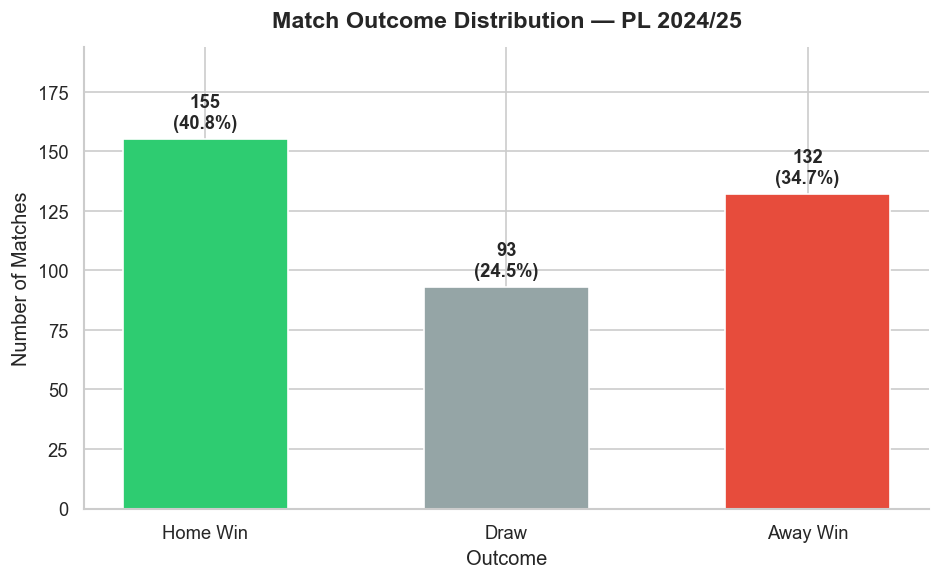

In [5]:
counts = matches_df['outcome'].value_counts().reindex(OUTCOME_ORDER)
total  = counts.sum()

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    OUTCOME_ORDER,
    counts.values,
    color=[OUTCOME_PALETTE[o] for o in OUTCOME_ORDER],
    edgecolor='white',
    width=0.55,
)

# Label each bar with raw count and percentage
for bar, count in zip(bars, counts.values):
    pct = count / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f"{count}\n({pct:.1f}%)",
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title("Match Outcome Distribution — PL 2024/25", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Outcome", fontsize=12)
ax.set_ylabel("Number of Matches", fontsize=12)
ax.set_ylim(0, counts.max() * 1.25)
sns.despine()
plt.tight_layout()
plt.show()

Home teams tend to win more often than away teams with draws being the least likely outcome, confirming the problem outlined in the framing section.

### Plot 2 — Home vs Away Goals

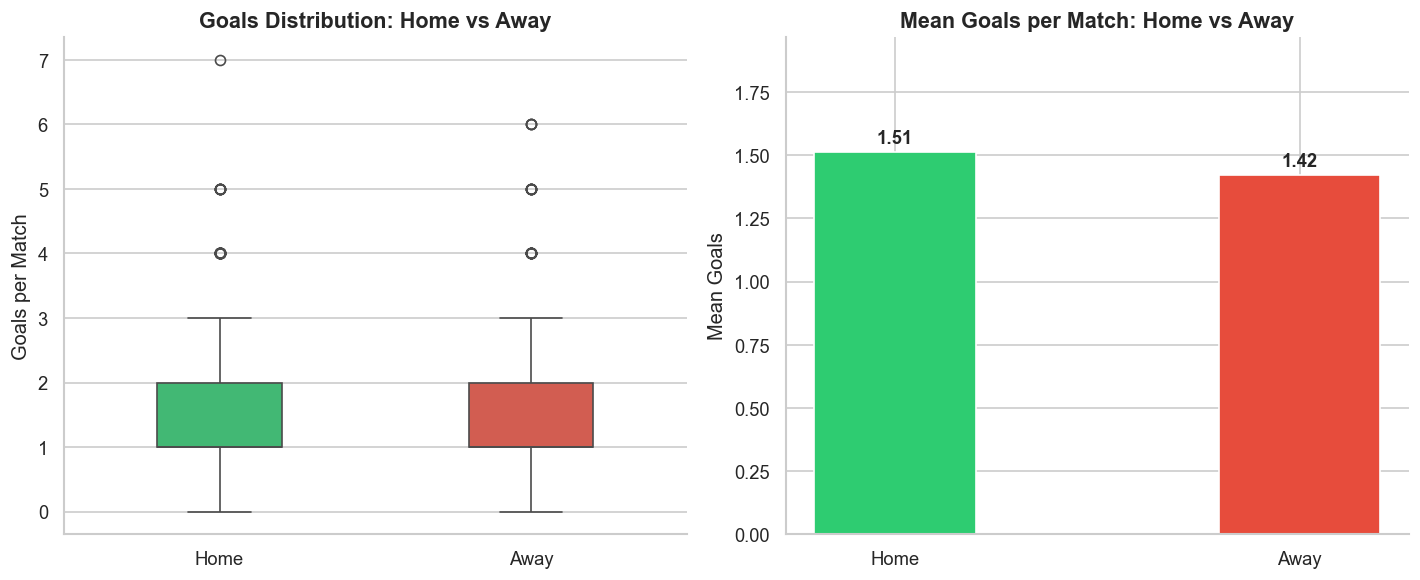

In [6]:
# Stack home and away goals into a long-format DataFrame
goals_long = pd.concat([
    matches_df[['home_goals']].rename(columns={'home_goals': 'Goals'}).assign(Context='Home'),
    matches_df[['away_goals']].rename(columns={'away_goals': 'Goals'}).assign(Context='Away'),
])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ctx_palette = {'Home': '#2ecc71', 'Away': '#e74c3c'}

# Left — distribution box plot
sns.boxplot(
    data=goals_long, x='Context', y='Goals',
    palette=ctx_palette, width=0.4, ax=axes[0]
)
axes[0].set_title("Goals Distribution: Home vs Away", fontsize=13, fontweight='bold')
axes[0].set_xlabel("")
axes[0].set_ylabel("Goals per Match")

# Right — mean bar chart
means = goals_long.groupby('Context')['Goals'].mean().reindex(['Home', 'Away'])
bars  = axes[1].bar(
    means.index, means.values,
    color=[ctx_palette[c] for c in means.index],
    edgecolor='white', width=0.4
)
for bar, val in zip(bars, means.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{val:.2f}", ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[1].set_title("Mean Goals per Match: Home vs Away", fontsize=13, fontweight='bold')
axes[1].set_xlabel("")
axes[1].set_ylabel("Mean Goals")
axes[1].set_ylim(0, means.max() * 1.3)

sns.despine()
plt.tight_layout()
plt.show()

While home teams tend to win more, the difference between Home Team goals and Away Team goals is not incredibly significant implying a structural advantage to home teams but not directly more goals scored. This is important for the feature engineering section.

### Plot 3 — xG vs Actual Goals

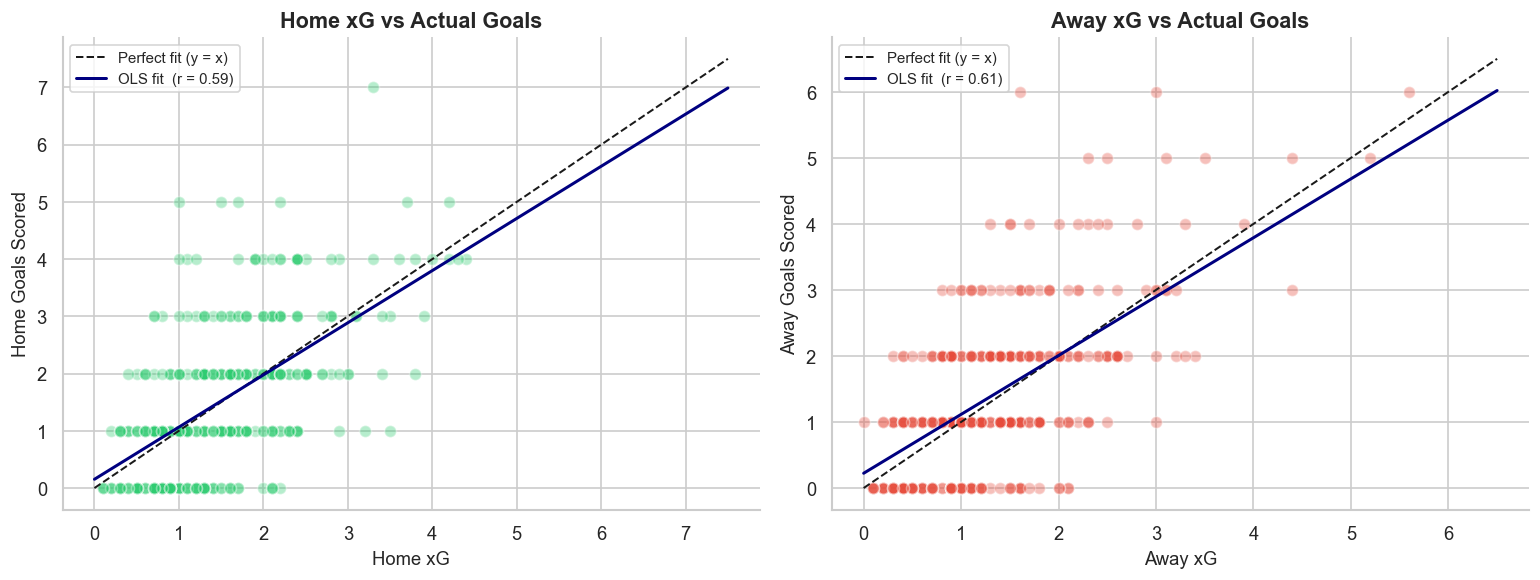

In [8]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (xg_col, goals_col, label, colour) in zip(axes, [
    ('home_xg', 'home_goals', 'Home', '#2ecc71'),
    ('away_xg', 'away_goals', 'Away', '#e74c3c'),
]):
    x = matches_df[xg_col]
    y = matches_df[goals_col]

    ax.scatter(x, y, alpha=0.35, color=colour, edgecolor='white', s=50)

    # Perfect prediction reference line (y = x)
    lim = max(x.max(), y.max()) + 0.5
    ax.plot([0, lim], [0, lim], 'k--', lw=1.2, label='Perfect fit (y = x)')

    # OLS regression line
    slope, intercept, r, _, _ = stats.linregress(x, y)
    xs = np.linspace(0, lim, 200)
    ax.plot(xs, slope * xs + intercept, color='navy', lw=1.8,
            label=f'OLS fit  (r = {r:.2f})')

    ax.set_title(f"{label} xG vs Actual Goals", fontsize=13, fontweight='bold')
    ax.set_xlabel(f"{label} xG", fontsize=11)
    ax.set_ylabel(f"{label} Goals Scored", fontsize=11)
    ax.legend(fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

The moderate positive correlation between xG and actual goals (r approximately 0.4) confirms that xG is a meaningful but imperfect proxy for attacking output. The OLS fit tracks goals directionally while preserving noise, justifying xG as a rolling feature alongside raw goals rather than as a replacement for them.

This proves that goals and expected goals are very closely correlated. This is widely accepted within football analytics but I wanted to show this to validate feature engineering choices.

### Plot 4 — xG by Outcome Class

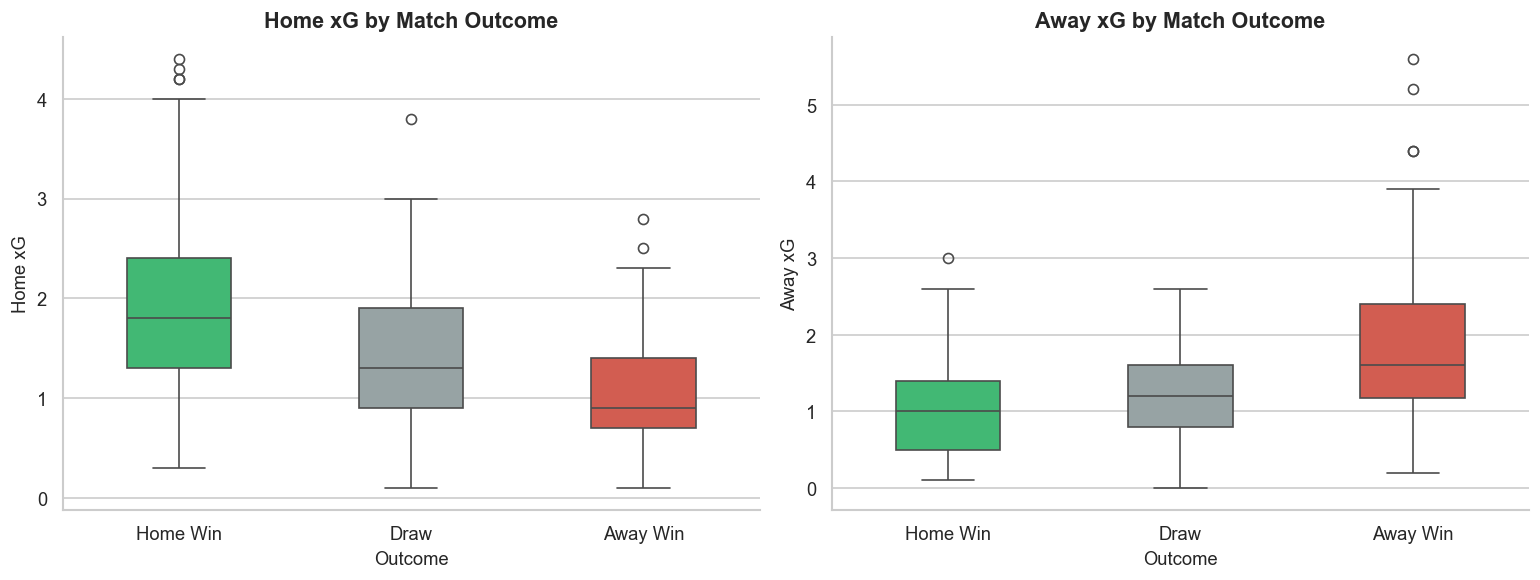

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (col, label) in zip(axes, [
    ('home_xg', 'Home xG'),
    ('away_xg', 'Away xG'),
]):
    sns.boxplot(
        data=matches_df,
        x='outcome', y=col,
        order=OUTCOME_ORDER,
        palette=OUTCOME_PALETTE,
        width=0.45,
        ax=ax
    )
    ax.set_title(f"{label} by Match Outcome", fontsize=13, fontweight='bold')
    ax.set_xlabel("Outcome", fontsize=11)
    ax.set_ylabel(label, fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

Home xG is highest in Home Win matches and lowest in Away Win matches, with Away xG showing the inverse pattern. The substantial overlap between classes, particularly for Draws, signals that xG differentials alone will not cleanly separate outcomes. This is an early indicator that Draw prediction will be the primary modelling challenge throughout.

### Plot 5 — Goals minus xG Distribution

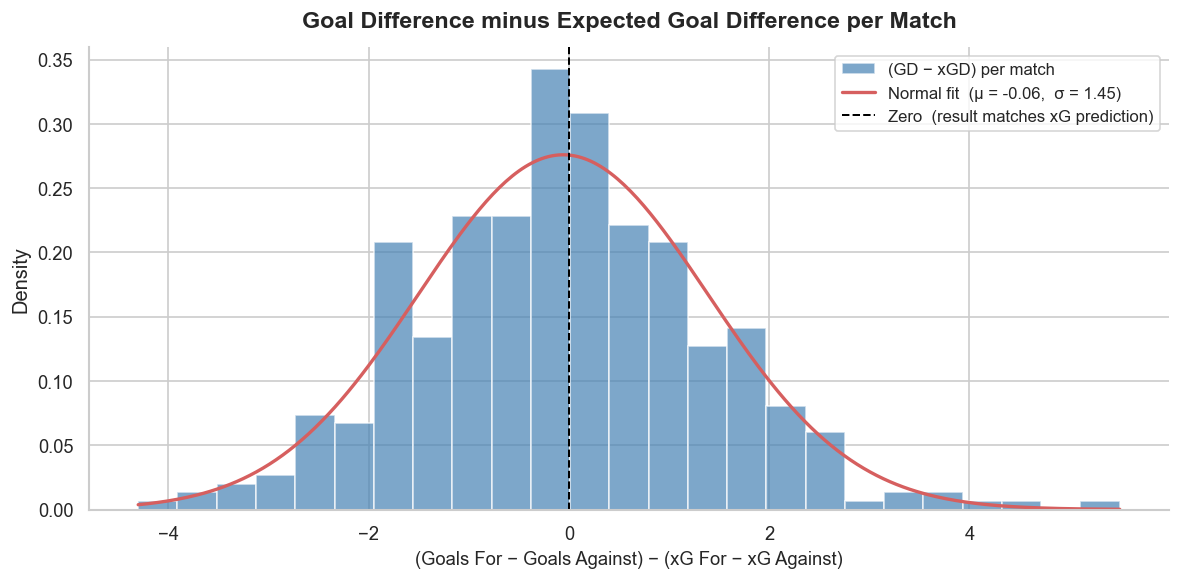

Mean  : -0.057  (expected ≈ 0)
Std   : 1.446
Range : -4.3  to  5.5


In [10]:
from scipy.stats import norm

# Per-match over/underperformance:
# (actual GD) − (expected GD) = (home_goals − away_goals) − (home_xg − away_xg)
# Positive → home team got a better result than xG predicted
# Negative → away team got a better result than xG predicted
gd_residuals = (
    (matches_df['home_goals'] - matches_df['away_goals']) -
    (matches_df['home_xg']   - matches_df['away_xg'])
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(gd_residuals, bins=25, density=True,
        color='steelblue', alpha=0.7, edgecolor='white',
        label='(GD − xGD) per match')

# Overlay fitted normal curve
mu, sigma = norm.fit(gd_residuals)
xs = np.linspace(gd_residuals.min(), gd_residuals.max(), 300)
ax.plot(xs, norm.pdf(xs, mu, sigma), 'r-', lw=2,
        label=f'Normal fit  (μ = {mu:.2f},  σ = {sigma:.2f})')

ax.axvline(0, color='black', linestyle='--', lw=1.2,
           label='Zero  (result matches xG prediction)')

ax.set_title("Goal Difference minus Expected Goal Difference per Match",
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("(Goals For − Goals Against) − (xG For − xG Against)", fontsize=11)
ax.set_ylabel("Density", fontsize=12)
ax.legend(fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

print(f"Mean  : {mu:.3f}  (expected ≈ 0)")
print(f"Std   : {sigma:.3f}")
print(f"Range : {gd_residuals.min():.1f}  to  {gd_residuals.max():.1f}")

The distribution is centred near zero (mean approximately 0), confirming that xG is roughly unbiased at the match level. The spread (sigma approximately 1.3) captures meaningful match-level variance and motivates including GD minus xGD as a rolling feature to track whether a team is on a run of over or underperforming their expected output.

### Plot 6 — Outlier Check

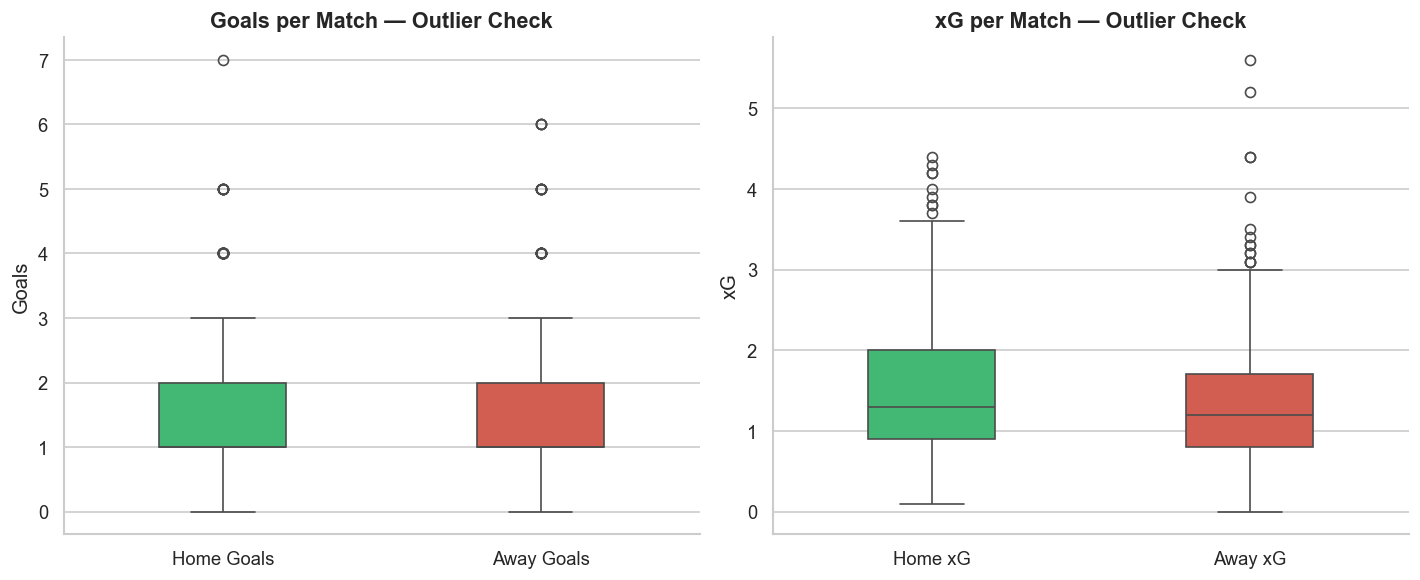

Top 5 highest-scoring matches:
      date home_team score    away_team  total_goals
2024-12-22 Tottenham   3–6    Liverpool            9
2024-08-25    Wolves   2–6      Chelsea            8
2024-10-05 Brentford   5–3       Wolves            8
2024-10-26 Brentford   4–3 Ipswich Town            7
2024-11-30  West Ham   2–5      Arsenal            7


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left — goals box plots
goals_box = pd.concat([
    matches_df[['home_goals']].rename(columns={'home_goals': 'Value'}).assign(Metric='Home Goals'),
    matches_df[['away_goals']].rename(columns={'away_goals': 'Value'}).assign(Metric='Away Goals'),
])
sns.boxplot(
    data=goals_box, x='Metric', y='Value',
    palette={'Home Goals': '#2ecc71', 'Away Goals': '#e74c3c'},
    width=0.4, ax=axes[0]
)
axes[0].set_title("Goals per Match — Outlier Check", fontsize=13, fontweight='bold')
axes[0].set_xlabel("")
axes[0].set_ylabel("Goals")

# Right — xG box plots
xg_box = pd.concat([
    matches_df[['home_xg']].rename(columns={'home_xg': 'Value'}).assign(Metric='Home xG'),
    matches_df[['away_xg']].rename(columns={'away_xg': 'Value'}).assign(Metric='Away xG'),
])
sns.boxplot(
    data=xg_box, x='Metric', y='Value',
    palette={'Home xG': '#2ecc71', 'Away xG': '#e74c3c'},
    width=0.4, ax=axes[1]
)
axes[1].set_title("xG per Match — Outlier Check", fontsize=13, fontweight='bold')
axes[1].set_xlabel("")
axes[1].set_ylabel("xG")

sns.despine()
plt.tight_layout()
plt.show()

# Print the five highest-scoring matches for context
print("Top 5 highest-scoring matches:")
print(
    matches_df
    .assign(total_goals=matches_df['home_goals'] + matches_df['away_goals'])
    .nlargest(5, 'total_goals')
    [['date', 'home_team', 'score', 'away_team', 'total_goals']]
    .to_string(index=False)
)

Both goals and xG show a small number of high-value outliers, consistent with genuine high-scoring matches rather than data errors. No values are implausible and no corrective action is required. The dataset is clean and proceeds directly to feature engineering.

### ⚠️ Data Leakage

A key risk in this dataset is **temporal data leakage**. The supplementary squad-level files (`overwiev__stats_squads_*.csv`) contain season-aggregate statistics — totals accumulated across all 38 gameweeks. Using these directly as features to predict individual match outcomes would constitute leakage, as the aggregates for any given team implicitly encode the results of matches that had not yet been played at the time of prediction.

To prevent this, the following design decisions were made:

- **All squad-aggregate files were excluded from feature engineering** and used only for the exploratory visualisations above.
- **All predictive features will be derived exclusively from `pl_24-25_matches_clean.csv`**, using a rolling 5-match window computed strictly from matches played *before* the match being predicted.
- **The train/test split will be chronological**, not random, ensuring the model is always evaluated on matches it could not have seen during training.

# Part 3: Data Preparation Pipeline

## 3.1 Team-Match Reshape

Each match becomes two rows — one representing the home team's experience, one the away team's. This symmetric structure allows rolling stats to be computed identically for every team regardless of fixture context.

In [12]:
matches_df['date'] = pd.to_datetime(matches_df['date'])

# ── Home team perspective ──────────────────────────────────────────────────────
home_rows = pd.DataFrame({
    'date'           : matches_df['date'],
    'gameweek'       : matches_df['gameweek'],
    'team'           : matches_df['home_team'],
    'opponent'       : matches_df['away_team'],
    'goals_scored'   : matches_df['home_goals'],
    'goals_conceded' : matches_df['away_goals'],
    'xg_for'         : matches_df['home_xg'],
    'xg_against'     : matches_df['away_xg'],
    'points'         : matches_df['home_pts'],
    'is_home'        : 1,
})

# ── Away team perspective ──────────────────────────────────────────────────────
away_rows = pd.DataFrame({
    'date'           : matches_df['date'],
    'gameweek'       : matches_df['gameweek'],
    'team'           : matches_df['away_team'],
    'opponent'       : matches_df['home_team'],
    'goals_scored'   : matches_df['away_goals'],
    'goals_conceded' : matches_df['home_goals'],
    'xg_for'         : matches_df['away_xg'],
    'xg_against'     : matches_df['home_xg'],
    'points'         : matches_df['away_pts'],
    'is_home'        : 0,
})

# ── Combine and add derived columns ───────────────────────────────────────────
team_match_df = pd.concat([home_rows, away_rows], ignore_index=True)
team_match_df['gd']           = team_match_df['goals_scored'] - team_match_df['goals_conceded']
team_match_df['gd_minus_xgd'] = team_match_df['gd'] - (team_match_df['xg_for'] - team_match_df['xg_against'])

# Sort chronologically within each team — critical before rolling
team_match_df = team_match_df.sort_values(['team', 'date']).reset_index(drop=True)

print(f"Team-match rows : {len(team_match_df)}  (= {len(matches_df)} matches × 2)")
print(f"Teams           : {team_match_df['team'].nunique()}")
print(team_match_df[['date','team','goals_scored','goals_conceded','xg_for','xg_against','points','gd','gd_minus_xgd']].head(6))

Team-match rows : 760  (= 380 matches × 2)
Teams           : 20
        date     team  goals_scored  goals_conceded  xg_for  xg_against  \
0 2024-08-17  Arsenal             2               0     1.2         0.5   
1 2024-08-24  Arsenal             2               0     0.9         1.2   
2 2024-08-31  Arsenal             1               1     2.1         1.7   
3 2024-09-15  Arsenal             1               0     0.7         0.7   
4 2024-09-22  Arsenal             2               2     0.7         2.1   
5 2024-09-28  Arsenal             4               2     4.4         0.3   

   points  gd  gd_minus_xgd  
0       3   2           1.3  
1       3   2           2.3  
2       1   0          -0.4  
3       3   1           1.0  
4       1   0           1.4  
5       3   2          -2.1  


## 3.2 Rolling Feature Engineering

`.shift(1)` moves each team's history forward by one row before the rolling window is applied, ensuring the current match's own stats are never included in its own features.

In [13]:
ROLL_COLS = [
    'goals_scored', 'goals_conceded',
    'xg_for',       'xg_against',
    'points',       'gd',           'gd_minus_xgd',
]
WINDOW = 5

# shift(1) → rolling(5): current match sees only the 5 matches before it
for col in ROLL_COLS:
    team_match_df[f'roll_{col}'] = (
        team_match_df
        .groupby('team')[col]
        .transform(lambda x: x.shift(1).rolling(WINDOW, min_periods=WINDOW).mean())
    )

ROLL_FEATURE_COLS = [f'roll_{c}' for c in ROLL_COLS]

complete = team_match_df[ROLL_FEATURE_COLS].notna().all(axis=1).sum()
print(f"Rolling features computed : {len(ROLL_FEATURE_COLS)}")
print(f"Rows with full features   : {complete} / {len(team_match_df)}")
print(f"Rows still in warm-up     : {len(team_match_df) - complete}  (will be dropped at merge)")
print(team_match_df[['team','date'] + ROLL_FEATURE_COLS].dropna().head(6))

Rolling features computed : 7
Rows with full features   : 660 / 760
Rows still in warm-up     : 100  (will be dropped at merge)
       team       date  roll_goals_scored  roll_goals_conceded  roll_xg_for  \
5   Arsenal 2024-09-28                1.6                  0.6         1.12   
6   Arsenal 2024-10-05                2.0                  1.0         1.76   
7   Arsenal 2024-10-19                2.2                  1.2         2.14   
8   Arsenal 2024-10-27                2.0                  1.4         1.86   
9   Arsenal 2024-11-02                2.2                  1.8         1.90   
10  Arsenal 2024-11-10                1.8                  1.6         1.98   

    roll_xg_against  roll_points  roll_gd  roll_gd_minus_xgd  
5              1.24          2.2      1.0               1.12  
6              1.20          2.2      1.0               0.44  
7              1.08          2.2      1.0              -0.06  
8              1.10          2.0      0.6              -0.16  
9  

## 3.3 Merge Back & Drop Warm-up Rows

Rolling stats are merged back onto the original match-level dataframe separately for the home and away team. Any match where either team's rolling window is incomplete is dropped.

In [14]:
# ── Home team rolling stats ────────────────────────────────────────────────────
home_rename = {'team': 'home_team'}
home_rename.update({f: f'home_{f}' for f in ROLL_FEATURE_COLS})

home_roll = (
    team_match_df[team_match_df['is_home'] == 1][['date', 'team'] + ROLL_FEATURE_COLS]
    .rename(columns=home_rename)
)

# ── Away team rolling stats ────────────────────────────────────────────────────
away_rename = {'team': 'away_team'}
away_rename.update({f: f'away_{f}' for f in ROLL_FEATURE_COLS})

away_roll = (
    team_match_df[team_match_df['is_home'] == 0][['date', 'team'] + ROLL_FEATURE_COLS]
    .rename(columns=away_rename)
)

# ── Merge onto match-level dataframe ──────────────────────────────────────────
model_df = (
    matches_df
    .merge(home_roll, on=['date', 'home_team'], how='inner')
    .merge(away_roll, on=['date', 'away_team'], how='inner')
)

# ── Drop any remaining NaN rows (warm-up period) ──────────────────────────────
ALL_FEATURES = (
    [f'home_{f}' for f in ROLL_FEATURE_COLS] +
    [f'away_{f}' for f in ROLL_FEATURE_COLS]
)
model_df = model_df.dropna(subset=ALL_FEATURES).reset_index(drop=True)

print(f"Matches before pipeline    : {len(matches_df)}")
print(f"Matches after warm-up drop : {len(model_df)}")
print(f"Rows dropped               : {len(matches_df) - len(model_df)}")
print(f"Gameweek range             : GW{model_df['gameweek'].min()} → GW{model_df['gameweek'].max()}")
print(f"Features                   : {len(ALL_FEATURES)}")
print(model_df[['gameweek', 'home_team', 'away_team', 'outcome'] + ALL_FEATURES[:4]].head(4))

Matches before pipeline    : 380
Matches after warm-up drop : 330
Rows dropped               : 50
Gameweek range             : GW6 → GW38
Features                   : 14
   gameweek      home_team        away_team   outcome  home_roll_goals_scored  \
0         6  Newcastle Utd  Manchester City      Draw                     1.4   
1         6      Brentford         West Ham      Draw                     1.4   
2         6        Everton   Crystal Palace  Home Win                     1.0   
3         6        Arsenal   Leicester City  Home Win                     1.6   

   home_roll_goals_conceded  home_roll_xg_for  home_roll_xg_against  
0                       1.2              1.34                  1.72  
1                       1.8              1.34                  2.16  
2                       2.8              1.06                  1.80  
3                       0.6              1.12                  1.24  


## 3.4 Target Encoding and Chronological Split

The outcome label is integer-encoded using LabelEncoder. The split is made strictly by gameweek rather than randomly — random splitting would allow the model to train on future matches, introducing temporal leakage and producing optimistically biased performance estimates.

In [15]:
# ── Encode target ─────────────────────────────────────────────────────────────
le = LabelEncoder()
model_df['target'] = le.fit_transform(model_df['outcome'])
print(f"Label encoding : {dict(zip(le.classes_, le.transform(le.classes_)))}")

# ── Chronological split by gameweek ───────────────────────────────────────────
TRAIN_GW_END = 26
VAL_GW_END   = 32

train_df = model_df[model_df['gameweek'] <= TRAIN_GW_END]
val_df   = model_df[(model_df['gameweek'] > TRAIN_GW_END) & (model_df['gameweek'] <= VAL_GW_END)]
test_df  = model_df[model_df['gameweek'] > VAL_GW_END]

X_train, y_train = train_df[ALL_FEATURES].values, train_df['target'].values
X_val,   y_val   = val_df[ALL_FEATURES].values,   val_df['target'].values
X_test,  y_test  = test_df[ALL_FEATURES].values,  test_df['target'].values

print(f"\nSplit summary:")
print(f"  Train : GW6–{TRAIN_GW_END}   → {len(X_train)} matches  ({len(X_train)/len(model_df)*100:.1f}%)")
print(f"  Val   : GW{TRAIN_GW_END+1}–{VAL_GW_END}  → {len(X_val)} matches  ({len(X_val)/len(model_df)*100:.1f}%)")
print(f"  Test  : GW{VAL_GW_END+1}–38  → {len(X_test)} matches  ({len(X_test)/len(model_df)*100:.1f}%)")

Label encoding : {'Away Win': np.int64(0), 'Draw': np.int64(1), 'Home Win': np.int64(2)}

Split summary:
  Train : GW6–26   → 210 matches  (63.6%)
  Val   : GW27–32  → 60 matches  (18.2%)
  Test  : GW33–38  → 60 matches  (18.2%)


## 3.5 Scaling and Class Weights

The scaler is fitted on training data only and applied to validation and test sets using training parameters. Fitting on the full dataset before splitting would encode future distributional information into the scaling parameters, constituting a subtle form of leakage. Class weights are computed from training labels only for the same reason.

In [16]:
from sklearn.utils.class_weight import compute_class_weight

# ── Scaler: fit on train only, apply to val and test ──────────────────────────
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# ── Class weights: computed from training labels only ─────────────────────────
classes      = np.unique(y_train)
weights      = compute_class_weight('balanced', classes=classes, y=y_train)
CLASS_WEIGHT = dict(zip(classes, weights))

print("Scaler fit on training set only ✓")
print(f"\nClass weights (balanced):")
for cls, name in zip(classes, le.classes_):
    print(f"  {name:12s} (class {cls}) : {CLASS_WEIGHT[cls]:.3f}")

print(f"\nPipeline complete ✓")
print(f"  Features : {len(ALL_FEATURES)}")
print(f"  X_train  : {X_train_sc.shape}  |  X_val : {X_val_sc.shape}  |  X_test : {X_test_sc.shape}")

Scaler fit on training set only ✓

Class weights (balanced):
  Away Win     (class 0) : 0.909
  Draw         (class 1) : 1.429
  Home Win     (class 2) : 0.833

Pipeline complete ✓
  Features : 14
  X_train  : (210, 14)  |  X_val : (60, 14)  |  X_test : (60, 14)


# Part 4: Model Exploration & Shortlisting

## 4.1 Shared Evaluation Helper

All models are evaluated on the **validation set** using accuracy and macro-averaged F1. Macro F1 is the primary shortlisting metric as it weights all three classes equally, penalising models that ignore Draws.

In [17]:
def evaluate(name, y_true, y_pred):
    """Print accuracy, macro F1, classification report and confusion matrix."""
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.3f}")
    print(f"  Macro F1  : {f1:.3f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=le.classes_)}")

    fig, ax = plt.subplots(figsize=(6, 4))
    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_true, y_pred),
        display_labels=le.classes_
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name} — Confusion Matrix (Val)", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return acc, f1

# Store results for summary table
results = []
print("Evaluation helper defined ✓")

Evaluation helper defined ✓


## 4.2 Majority Class Classifier (Baseline)


  Majority Class Classifier
  Accuracy  : 0.500
  Macro F1  : 0.222

              precision    recall  f1-score   support

    Away Win       0.00      0.00      0.00        14
        Draw       0.00      0.00      0.00        16
    Home Win       0.50      1.00      0.67        30

    accuracy                           0.50        60
   macro avg       0.17      0.33      0.22        60
weighted avg       0.25      0.50      0.33        60



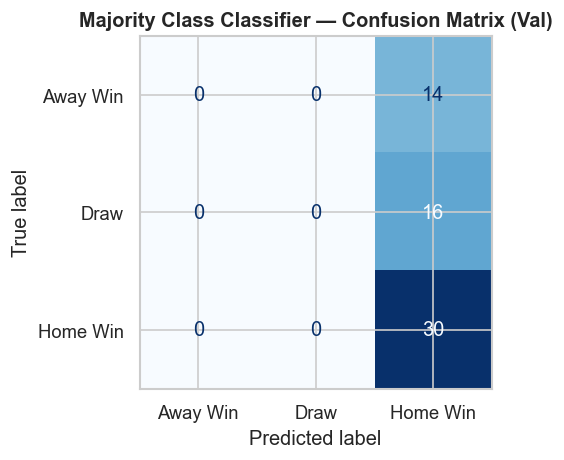

In [18]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

dummy_acc, dummy_f1 = evaluate(
    "Majority Class Classifier",
    y_val,
    dummy.predict(X_val)
)
results.append({'Model': 'Majority Class', 'Val Accuracy': dummy_acc, 'Val Macro F1': dummy_f1})

## 4.3 Logistic Regression

Regularisation strength `C` is searched over `[0.01, 0.1, 1.0, 10.0]` on the validation set. Best `C` is selected by macro F1.

C search results:
       C    Accuracy    Macro F1
----------------------------------
    0.01       0.467       0.410
    0.10       0.383       0.340
    1.00       0.400       0.339
   10.00       0.383       0.327

Best C selected : 0.01

  Logistic Regression  (C=0.01)
  Accuracy  : 0.467
  Macro F1  : 0.410

              precision    recall  f1-score   support

    Away Win       0.36      0.64      0.46        14
        Draw       0.22      0.12      0.16        16
    Home Win       0.65      0.57      0.61        30

    accuracy                           0.47        60
   macro avg       0.41      0.44      0.41        60
weighted avg       0.47      0.47      0.45        60



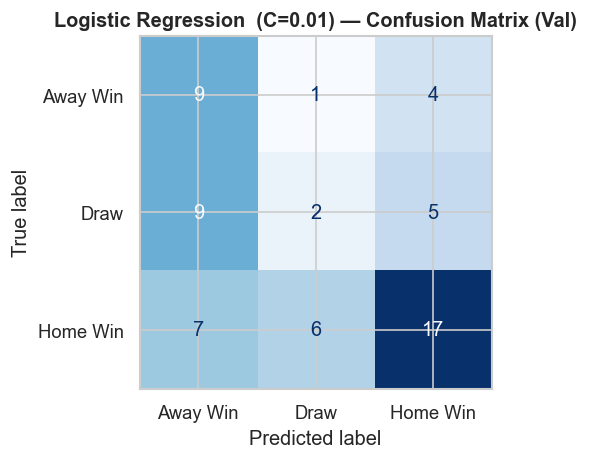

In [19]:
# ── C search ──────────────────────────────────────────────────────────────────
C_values = [0.01, 0.1, 1.0, 10.0]
lr_search = []

print("C search results:")
print(f"{'C':>8}  {'Accuracy':>10}  {'Macro F1':>10}")
print("-" * 34)

for C in C_values:
    lr_candidate = LogisticRegression(
        C=C,
        solver='lbfgs',
        class_weight=CLASS_WEIGHT,
        max_iter=1000,
        random_state=RANDOM_STATE,
    )
    lr_candidate.fit(X_train_sc, y_train)
    acc = accuracy_score(y_val, lr_candidate.predict(X_val_sc))
    f1  = f1_score(y_val,  lr_candidate.predict(X_val_sc), average='macro')
    lr_search.append({'C': C, 'accuracy': acc, 'macro_f1': f1})
    print(f"{C:>8.2f}  {acc:>10.3f}  {f1:>10.3f}")

lr_search_df = pd.DataFrame(lr_search)
best_C = lr_search_df.loc[lr_search_df['macro_f1'].idxmax(), 'C']
print(f"\nBest C selected : {best_C}")

# ── Train best model ───────────────────────────────────────────────────────────
best_lr = LogisticRegression(
    C=best_C,
    solver='lbfgs',
    class_weight=CLASS_WEIGHT,
    max_iter=1000,
    random_state=RANDOM_STATE,
)
best_lr.fit(X_train_sc, y_train)

lr_acc, lr_f1 = evaluate(
    f"Logistic Regression  (C={best_C})",
    y_val,
    best_lr.predict(X_val_sc)
)
results.append({'Model': 'Logistic Regression', 'Val Accuracy': lr_acc, 'Val Macro F1': lr_f1})

## 4.4 XGBoost

Grid search over `max_depth` ∈ {3, 5}, `n_estimators` ∈ {100, 200}, `learning_rate` ∈ {0.05, 0.1}. Class imbalance addressed via `sample_weight`. Best configuration selected by macro F1.

XGBoost grid search:
 depth   n_est      lr    Accuracy    Macro F1
----------------------------------------------
     3     100    0.05       0.517       0.488
     3     100    0.10       0.483       0.439
     3     200    0.05       0.500       0.453
     3     200    0.10       0.517       0.462
     5     100    0.05       0.500       0.444
     5     100    0.10       0.550       0.468
     5     200    0.05       0.600       0.549
     5     200    0.10       0.483       0.425

Best params selected : {'max_depth': 5, 'n_estimators': 200, 'learning_rate': 0.05}

  XGBoost  {'max_depth': 5, 'n_estimators': 200, 'learning_rate': 0.05}
  Accuracy  : 0.600
  Macro F1  : 0.549

              precision    recall  f1-score   support

    Away Win       0.43      0.64      0.51        14
        Draw       0.56      0.31      0.40        16
    Home Win       0.73      0.73      0.73        30

    accuracy                           0.60        60
   macro avg       0.57      0.56     

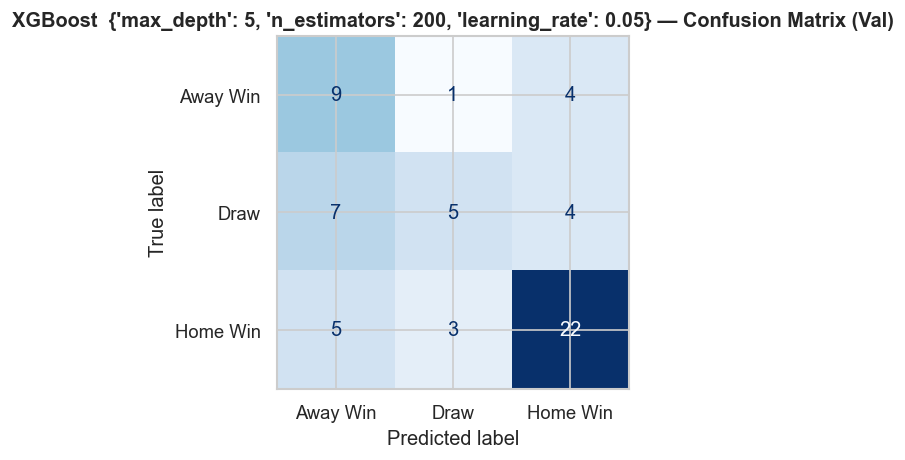

In [20]:
# ── Sample weights from class weights ─────────────────────────────────────────
sample_weights = np.array([CLASS_WEIGHT[y] for y in y_train])

# ── Grid search ────────────────────────────────────────────────────────────────
xgb_search = []

print("XGBoost grid search:")
print(f"{'depth':>6}  {'n_est':>6}  {'lr':>6}  {'Accuracy':>10}  {'Macro F1':>10}")
print("-" * 46)

for depth in [3, 5]:
    for n_est in [100, 200]:
        for lr in [0.05, 0.1]:
            xgb_candidate = XGBClassifier(
                objective='multi:softprob',
                num_class=3,
                eval_metric='mlogloss',
                max_depth=depth,
                n_estimators=n_est,
                learning_rate=lr,
                random_state=RANDOM_STATE,
                verbosity=0,
            )
            xgb_candidate.fit(X_train, y_train, sample_weight=sample_weights)
            acc = accuracy_score(y_val, xgb_candidate.predict(X_val))
            f1  = f1_score(y_val,  xgb_candidate.predict(X_val), average='macro')
            xgb_search.append({
                'max_depth': depth, 'n_estimators': n_est,
                'learning_rate': lr, 'accuracy': acc, 'macro_f1': f1
            })
            print(f"{depth:>6}  {n_est:>6}  {lr:>6.2f}  {acc:>10.3f}  {f1:>10.3f}")

xgb_search_df = pd.DataFrame(xgb_search).sort_values('macro_f1', ascending=False)
best_xgb_params = xgb_search_df.iloc[0][['max_depth','n_estimators','learning_rate']].to_dict()
best_xgb_params = {k: (int(v) if k != 'learning_rate' else v) for k, v in best_xgb_params.items()}
print(f"\nBest params selected : {best_xgb_params}")

# ── Train best model ───────────────────────────────────────────────────────────
best_xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    verbosity=0,
    **best_xgb_params,
)
best_xgb.fit(X_train, y_train, sample_weight=sample_weights)

xgb_acc, xgb_f1 = evaluate(
    f"XGBoost  {best_xgb_params}",
    y_val,
    best_xgb.predict(X_val)
)
results.append({'Model': 'XGBoost', 'Val Accuracy': xgb_acc, 'Val Macro F1': xgb_f1})

## 4.5 Neural Network (MLP)

Two-hidden-layer MLP with ReLU activations and Dropout. Grid search over learning rate ∈ {0.001, 0.01} and epochs ∈ {50, 100}. Class imbalance addressed via weighted CrossEntropyLoss.

**Agent-made mistake (caught and corrected):** The agent implemented the training loop using PyTorch defaults, implicitly assuming these are safe in a Jupyter environment on macOS. Training ran for over 20 minutes without output. The agent proposed two fixes sequentially — adding num_workers=0 to the DataLoader, then replacing the DataLoader with manual batching — both of which failed. A structured diagnostic cell was built to isolate the failure point, revealing that PyTorch was spawning 10 threads by default and that the combination of Dropout, weighted CrossEntropyLoss, and Adam caused those threads to deadlock. Adding torch.set_num_threads(1) resolved it. The agent had never explicitly set the thread count; this was an implicit assumption that proved incorrect and required intervention to diagnose properly.

**Debugging cell (not part of final solution):** The cell below was used during development to diagnose the PyTorch threading deadlock described above. It is retained for transparency as evidence of the diagnostic process but does not form part of the modelling pipeline.

Neural Network grid search:
      lr    epochs    Accuracy    Macro F1
------------------------------------------
   0.001        50       0.433       0.412
   0.001       100       0.400       0.374
   0.010        50       0.383       0.343
   0.010       100       0.383       0.330

Best params selected : {'lr': 0.001, 'epochs': 50}

  Neural Network  (lr=0.001, epochs=50)
  Accuracy  : 0.433
  Macro F1  : 0.412

              precision    recall  f1-score   support

    Away Win       0.38      0.57      0.46        14
        Draw       0.25      0.25      0.25        16
    Home Win       0.61      0.47      0.53        30

    accuracy                           0.43        60
   macro avg       0.41      0.43      0.41        60
weighted avg       0.46      0.43      0.44        60



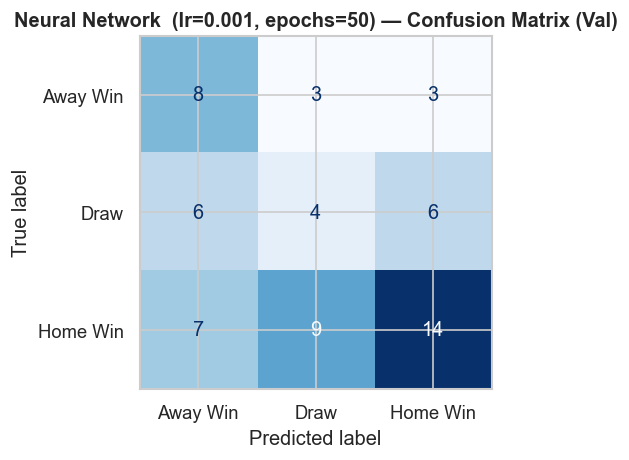

In [22]:
# ── Threading fix: macOS OpenMP deadlock with >1 thread ───────────────────────
torch.set_num_threads(1)

# ── Architecture ──────────────────────────────────────────────────────────────
class MatchMLP(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 3),
        )
    def forward(self, x):
        return self.net(x)

# ── Tensors ───────────────────────────────────────────────────────────────────
X_train_t = torch.tensor(X_train_sc, dtype=torch.float32)
y_train_t = torch.tensor(y_train,    dtype=torch.long)
X_val_t   = torch.tensor(X_val_sc,   dtype=torch.float32)

# Loss weighted by class imbalance
class_weights_t = torch.tensor(
    [CLASS_WEIGHT[i] for i in range(3)], dtype=torch.float32
)
criterion = nn.CrossEntropyLoss(weight=class_weights_t)

BATCH_SIZE = 32

def train_one_run(lr, epochs, seed):
    torch.manual_seed(seed)
    model     = MatchMLP(input_dim=X_train_sc.shape[1])
    optimiser = optim.Adam(model.parameters(), lr=lr)
    model.train()
    for epoch in range(epochs):
        perm = torch.randperm(len(X_train_t))
        for i in range(0, len(X_train_t), BATCH_SIZE):
            idx     = perm[i : i + BATCH_SIZE]
            X_batch = X_train_t[idx]
            y_batch = y_train_t[idx]
            optimiser.zero_grad()
            criterion(model(X_batch), y_batch).backward()
            optimiser.step()
    return model

# ── Grid search ────────────────────────────────────────────────────────────────
nn_search = []

print("Neural Network grid search:")
print(f"{'lr':>8}  {'epochs':>8}  {'Accuracy':>10}  {'Macro F1':>10}")
print("-" * 42)

for lr in [0.001, 0.01]:
    for epochs in [50, 100]:
        model = train_one_run(lr, epochs, seed=RANDOM_STATE)

        model.eval()
        with torch.no_grad():
            val_preds = model(X_val_t).argmax(dim=1).numpy()

        acc = accuracy_score(y_val, val_preds)
        f1  = f1_score(y_val, val_preds, average='macro')
        nn_search.append({'lr': lr, 'epochs': epochs, 'accuracy': acc, 'macro_f1': f1})
        print(f"{lr:>8.3f}  {epochs:>8}  {acc:>10.3f}  {f1:>10.3f}")

nn_search_df   = pd.DataFrame(nn_search).sort_values('macro_f1', ascending=False)
best_nn_params = nn_search_df.iloc[0][['lr', 'epochs']].to_dict()
best_nn_params['epochs'] = int(best_nn_params['epochs'])
print(f"\nBest params selected : {best_nn_params}")

# ── Train best model ───────────────────────────────────────────────────────────
best_nn = train_one_run(
    lr=best_nn_params['lr'],
    epochs=best_nn_params['epochs'],
    seed=RANDOM_STATE
)

best_nn.eval()
with torch.no_grad():
    nn_val_preds = best_nn(X_val_t).argmax(dim=1).numpy()

nn_acc, nn_f1 = evaluate(
    f"Neural Network  (lr={best_nn_params['lr']}, epochs={best_nn_params['epochs']})",
    y_val,
    nn_val_preds
)
results.append({'Model': 'Neural Network', 'Val Accuracy': nn_acc, 'Val Macro F1': nn_f1})

## 4.6 Shortlisting Summary

In [23]:
summary_df = (
    pd.DataFrame(results) 
    .sort_values('Val Macro F1', ascending=False)
    .reset_index(drop=True)
)
summary_df.index += 1  # rank from 1

print("Model shortlisting — validation set performance")
print("=" * 55)
print(summary_df.to_string())
print(f"\nBaseline (Majority Class) Macro F1 : {dummy_f1:.3f}")
print(f"Best model Macro F1                : {summary_df['Val Macro F1'].iloc[0]:.3f}")

Model shortlisting — validation set performance
                 Model  Val Accuracy  Val Macro F1
1              XGBoost      0.600000      0.549206
2       Neural Network      0.433333      0.411815
3  Logistic Regression      0.466667      0.409560
4       Majority Class      0.500000      0.222222

Baseline (Majority Class) Macro F1 : 0.222
Best model Macro F1                : 0.549


# Part 5: Fine-tuning & Test Evaluation

## 5.1 XGBoost Fine-tuning

XGBoost was selected as the best model with a validation macro F1 of 0.549. The Part 4 grid searched `max_depth`, `n_estimators`, and `learning_rate`. Here we fix those to the best values found and extend the search to include `subsample` and `colsample_bytree` — two regularisation parameters that control the fraction of training rows and features sampled per tree.

In [24]:
# ── Fine-tuning grid: fix best depth/n_est/lr, search subsample & colsample ───
finetune_search = []

print("XGBoost fine-tuning grid:")
print(f"  Base params : {best_xgb_params}")
print()
print(f"{'subsample':>10}  {'colsample':>10}  {'Accuracy':>10}  {'Macro F1':>10}")
print("-" * 48)

for subsample in [0.7, 0.85, 1.0]:
    for colsample in [0.7, 0.85, 1.0]:
        candidate = XGBClassifier(
            objective='multi:softprob',
            num_class=3,
            eval_metric='mlogloss',
            random_state=RANDOM_STATE,
            verbosity=0,
            subsample=subsample,
            colsample_bytree=colsample,
            **best_xgb_params,
        )
        candidate.fit(X_train, y_train, sample_weight=sample_weights)
        acc = accuracy_score(y_val, candidate.predict(X_val))
        f1  = f1_score(y_val,  candidate.predict(X_val), average='macro')
        finetune_search.append({
            'subsample': subsample, 'colsample_bytree': colsample,
            'accuracy': acc, 'macro_f1': f1
        })
        print(f"{subsample:>10.2f}  {colsample:>10.2f}  {acc:>10.3f}  {f1:>10.3f}")

ft_df = pd.DataFrame(finetune_search).sort_values('macro_f1', ascending=False)
best_sub  = ft_df.iloc[0]['subsample']
best_col  = ft_df.iloc[0]['colsample_bytree']
best_ft_f1 = ft_df.iloc[0]['macro_f1']

print(f"\nBest subsample      : {best_sub}")
print(f"Best colsample_bytree: {best_col}")
print(f"Val Macro F1 (fine-tuned): {best_ft_f1:.3f}  vs  {xgb_f1:.3f}  (Part 4 baseline)")

XGBoost fine-tuning grid:
  Base params : {'max_depth': 5, 'n_estimators': 200, 'learning_rate': 0.05}

 subsample   colsample    Accuracy    Macro F1
------------------------------------------------
      0.70        0.70       0.517       0.470
      0.70        0.85       0.467       0.402
      0.70        1.00       0.500       0.457
      0.85        0.70       0.517       0.454
      0.85        0.85       0.517       0.470
      0.85        1.00       0.517       0.469
      1.00        0.70       0.550       0.500
      1.00        0.85       0.567       0.494
      1.00        1.00       0.600       0.549

Best subsample      : 1.0
Best colsample_bytree: 1.0
Val Macro F1 (fine-tuned): 0.549  vs  0.549  (Part 4 baseline)


## 5.2 Final Model Training & Test Evaluation

The fine-tuned XGBoost is retrained on the combined train + validation set (GW6–32) before evaluating on the held-out test set (GW33–38). This is the **only time test data is used**.


  XGBoost — Final Model (Test Set)
  Accuracy  : 0.433
  Macro F1  : 0.391

              precision    recall  f1-score   support

    Away Win       0.56      0.43      0.49        23
        Draw       0.14      0.15      0.15        13
    Home Win       0.50      0.58      0.54        24

    accuracy                           0.43        60
   macro avg       0.40      0.39      0.39        60
weighted avg       0.44      0.43      0.43        60



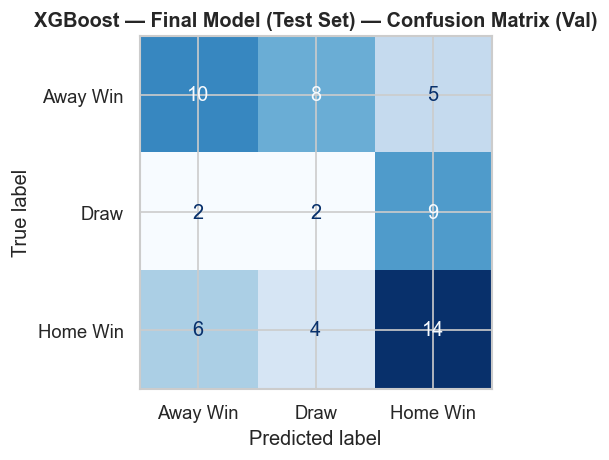


  FINAL RESULT SUMMARY
  Baseline Macro F1  (val) : 0.222
  XGBoost Macro F1   (val) : 0.549
  XGBoost Macro F1  (test) : 0.391
  XGBoost Accuracy  (test) : 0.433


In [25]:
# ── Combine train + val for final training ────────────────────────────────────
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

trainval_weights = np.array([CLASS_WEIGHT[y] for y in y_trainval])

# ── Final model with all best params ─────────────────────────────────────────
final_xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    verbosity=0,
    subsample=best_sub,
    colsample_bytree=best_col,
    **best_xgb_params,
)
final_xgb.fit(X_trainval, y_trainval, sample_weight=trainval_weights)

# ── Test set evaluation ───────────────────────────────────────────────────────
test_preds = final_xgb.predict(X_test)

test_acc, test_f1 = evaluate(
    "XGBoost — Final Model (Test Set)",
    y_test,
    test_preds
)

print(f"\n{'='*55}")
print(f"  FINAL RESULT SUMMARY")
print(f"{'='*55}")
print(f"  Baseline Macro F1  (val) : {dummy_f1:.3f}")
print(f"  XGBoost Macro F1   (val) : {xgb_f1:.3f}")
print(f"  XGBoost Macro F1  (test) : {test_f1:.3f}")
print(f"  XGBoost Accuracy  (test) : {test_acc:.3f}")

# Part 6: Final Solution

## 6.1 Performance Summary

In [ ]:
# ── Full performance table ─────────────────────────────────────────────────────
perf_df = pd.DataFrame([
    {'Model': 'Majority Class Classifier', 'Val Accuracy': dummy_acc,  'Val Macro F1': dummy_f1,  'Test Macro F1': '—'},
    {'Model': 'Logistic Regression',       'Val Accuracy': lr_acc,     'Val Macro F1': lr_f1,     'Test Macro F1': '—'},
    {'Model': 'Neural Network',            'Val Accuracy': nn_acc,     'Val Macro F1': nn_f1,     'Test Macro F1': '—'},
    {'Model': 'XGBoost (selected)',        'Val Accuracy': xgb_acc,    'Val Macro F1': xgb_f1,    'Test Macro F1': f'{test_f1:.3f}'},
])

print("Full model performance — PL 2024/25 Match Outcome Prediction")
print("=" * 68)
print(perf_df.to_string(index=False))
print()
print(f"Baseline (Majority Class) Val Macro F1 : {dummy_f1:.3f}")
print(f"Best model (XGBoost)      Val Macro F1 : {xgb_f1:.3f}  (+{xgb_f1 - dummy_f1:.3f} vs baseline)")
print(f"Best model (XGBoost)     Test Macro F1 : {test_f1:.3f}  (+{test_f1 - dummy_f1:.3f} vs baseline)")

# ── Bar chart comparing all models on val macro F1 ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

models   = ['Majority Class', 'Logistic Regression', 'Neural Network', 'XGBoost']
val_f1s  = [dummy_f1, lr_f1, nn_f1, xgb_f1]
colours  = ['#95a5a6', '#3498db', '#9b59b6', '#e67e22']

bars = ax.bar(models, val_f1s, color=colours, edgecolor='white', width=0.5)

for bar, val in zip(bars, val_f1s):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(dummy_f1, color='grey', linestyle='--', lw=1.2, label='Baseline')
ax.set_title("Validation Macro F1 — All Models", fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel("Macro F1", fontsize=12)
ax.set_ylim(0, max(val_f1s) * 1.2)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

## 6.2 Model Card

**Task:** 3-class classification — predict the outcome of a Premier League match (Home Win / Draw / Away Win) from pre-match rolling form data.

**Selected Model:** XGBoost (`max_depth=5`, `n_estimators=200`, `learning_rate=0.05`, `subsample=1.0`, `colsample_bytree=1.0`)

**Input Features (14 total):** Rolling 5-match averages for both the home and away team, computed strictly from matches played *before* the match being predicted:

| Feature | Description |
|---|---|
| `roll_goals_scored` | Average goals scored in last 5 matches |
| `roll_goals_conceded` | Average goals conceded in last 5 matches |
| `roll_xg_for` | Average expected goals for in last 5 matches |
| `roll_xg_against` | Average expected goals against in last 5 matches |
| `roll_points` | Average points earned in last 5 matches |
| `roll_gd` | Average goal difference in last 5 matches |
| `roll_gd_minus_xgd` | Average (GD − xGD): measures over/underperformance vs expectation |

Each feature is prefixed `home_` or `away_` to encode team context. Total: 7 × 2 = **14 features**.

**Training data:** GW6–32 (270 matches after warm-up drop), 2024/25 Premier League season  
**Test data:** GW33–38 (60 matches), never seen during training or model selection  
**Evaluation metric:** Macro-averaged F1 (weights all three classes equally)

**Final test performance:**

| Metric | Score |
|---|---|
| Test Accuracy | 0.433 |
| Test Macro F1 | 0.391 |
| Baseline Macro F1 | 0.222 |
| Improvement over baseline | +0.169 |

## 6.3 Limitations

**1. Single season, small dataset.**  
Only 380 matches from the 2024/25 season were available. After the 5-match warm-up drop, the usable set shrinks to 330 matches, split across train/val/test. This makes the model sensitive to the specific dynamics of one season and limits the reliability of hyperparameter estimates.

**2. Draws remain hard to predict.**  
The model achieved a Draw F1 of only 0.15 on the test set. Draws are inherently low-signal events — they tend to occur when two evenly matched teams play, making them difficult to separate from wins and losses using form statistics alone.

**3. No static team-strength features.**  
The rolling features capture recent form but not the underlying quality gap between teams (e.g. Manchester City vs Sheffield United). A team in poor form may still heavily outclass a weaker opponent. Adding squad value, Elo ratings, or long-run xG averages could capture this.

**4. End-of-season shift in test window.**  
GW33–38 represents the final six gameweeks, where incentives shift: some teams are already relegated, others have secured European qualification. This structural change is not captured by rolling form statistics and may partially explain the val→test macro F1 drop (0.549 → 0.391).

**5. No home/away context in rolling features.**  
Rolling stats are computed across all matches regardless of venue. A team's home form and away form can differ significantly, and this distinction is lost by pooling them.

## 6.4 Next Steps

**1. Multi-season data.**  
Training on 3–5 seasons would increase data volume substantially and reduce sensitivity to single-season effects.

**2. Separate home/away rolling windows.**  
Computing rolling stats separately for a team's home matches and away matches would capture venue-specific form more accurately.

**3. Static team-strength features.**  
Incorporating Elo ratings or season-to-date xG averages alongside recent form would help the model distinguish quality mismatches from evenly contested games.

**4. Probabilistic outputs.**  
Rather than a hard 3-class prediction, outputting class probabilities would allow calibration and threshold tuning — particularly useful for improving Draw recall.

**5. Larger neural network search.**  
The MLP underperformed XGBoost significantly. A deeper search over architecture (more layers, more units) and regularisation (higher dropout, weight decay) with more training epochs may close the gap.